In [1]:
# from pyFAI
import pyFAI
from pathlib import Path
from pyFAI.calibrant import Calibrant
from pyFAI.geometry import Geometry
from pyFAI.goniometer import SingleGeometry
from pyFAI.gui import jupyter
import fabio
from natsort import natsorted

In [28]:
exp_dir = Path(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\yiru_insitu_Dec2025\insitu_1p0M_MBAI_5")
poni_file = ""
# calibrant_file = Path(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\ito_calibrant.D")
calibrant_file = ""

if not Path(poni_file).is_file():
    poni_file = exp_dir.parent.glob("*.poni").__next__()
    if not Path(poni_file).is_file():
        raise FileNotFoundError("PONI file not found.")

if not Path(calibrant_file).is_file():
    calibrant_file = Path(exp_dir.parents[1], "ito_calibrant.D")
    if not calibrant_file.is_file():
        raise FileNotFoundError("Calibrant file not found.")

frame_files = natsorted(exp_dir.glob("*.tif"))
first_image = frame_files[0]

calibrant_file

WindowsPath('G:/Shared drives/Sutter-Fella Lab/ECRP-Project/results/beamtime_Dec2025/ito_calibrant.D')

Text(0.5, 1.0, 'insitu_1p0M_MBAI_5_00001.tif')

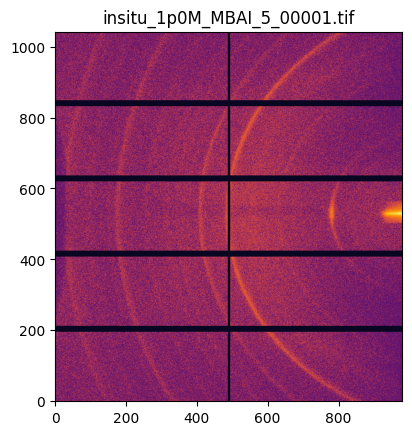

In [29]:
first_image = frame_files[0]
frame = fabio.open(first_image).data
ax = jupyter.display(frame)
ax.set_title(str(Path(first_image).name))

In [26]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def display_recalibration(sg: SingleGeometry, ax=None):

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    ax.imshow(sg.image, norm=LogNorm(), cmap='viridis')
    try:
        ai = sg.get_ai()
        shape = sg.image.shape
        tth = ai.center_array(shape, unit="2th_rad")
        # Get expected rings from calibrant
        rings = sg.calibrant.get_2th()
        # Filter rings that are within the image view vaguely (approx max tth)
        max_tth = tth.max()
        rings_visible = [r for r in rings if r < max_tth]
        
        if rings_visible:
                ax.contour(tth, levels=rings_visible, colors='r', linewidths=1)
        ax.set_title("Recalibration (Rings)")
    except Exception as e:
        print(f"Could not plot rings: {e}")
        ax.set_title("Recalibration (Image Only)")

Refining geometry with insitu_1p0M_MBAI_5_00001.tif
Refined geometry saved to G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\yiru_insitu_Dec2025\insitu_1p0M_MBAI_5\Recalibration_insitu_1p0M_MBAI_5.poni


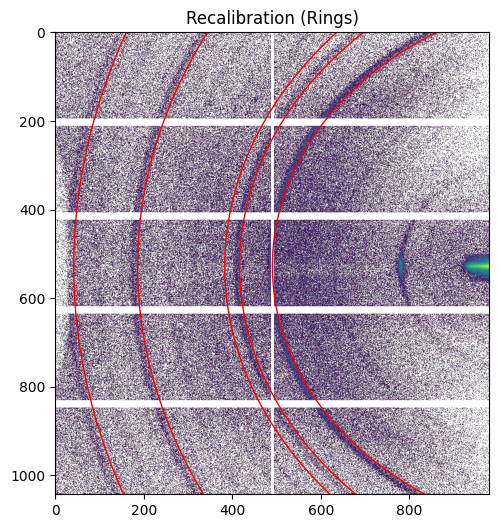

In [37]:
def refine_geometry(image_file, calibrant_file, initial_poni):

    print(f"Refining geometry with {str(Path(image_file).name)}")
    calibrant = Calibrant(filename=str(calibrant_file))
    initial_geometry = Geometry()
    initial_geometry.load(str(initial_poni))
    detector = initial_geometry.detector
    image = fabio.open(str(image_file)).data

    sg_label = "Recalibration_" + str(Path(image_file).parent.name)

    sg = SingleGeometry(sg_label, image, calibrant=calibrant, detector=detector, geometry=initial_geometry)
    sg.extract_cp(max_rings=5)
    sg.geometry_refinement.refine2()
    sg.get_ai()

    # jupyter.display(sg=sg)
    display_recalibration(sg)

    refined_poni_path = str(Path(image_file).parent / f"{sg_label}.poni")
    if Path(refined_poni_path).is_file():
        Path(refined_poni_path).unlink()
    sg.geometry_refinement.save(refined_poni_path)
    print(f"Refined geometry saved to {refined_poni_path}")

refine_geometry(first_image, calibrant_file, poni_file)
refined_poni = Path(exp_dir,f"Recalibration_{exp_dir.name}.poni")

In [ ]:
ai = pyFAI.load(str(refined_poni))

res = ai.integrate1d_ng(fabio.open(str(frame_files[200])).data,
                        500, unit="q_A^-1", azimuth_range=(-35, 35), radial_range=(0.4, 2.5))

res2 = ai.integrate2d_ng(fabio.open(str(first_image)).data,
                         500, 500, unit="2th_deg",
                         )

fig, (ax1, ax) = plt.subplots(1, 2, figsize=(12, 4))

jupyter.plot1d(res, ax=ax1)
ax1.set_yscale("log")
jupyter.plot2d(res2, ax=ax)
cb = fig.colorbar(ax.images[0], ax=ax)


In [ ]:
import datetime
import xarray as xr
import numpy as np
from tqdm import tqdm

def get_file_creation_time(file_path):
    p = Path(file_path)
    stat_result = p.stat()
    
    # Use st_birthtime if available (macOS/some Unix), otherwise use st_ctime (Windows/metadata change time on Unix)
    if hasattr(stat_result, 'st_birthtime'):
        timestamp = stat_result.st_birthtime
    else:
        timestamp = stat_result.st_ctime
        
    return datetime.datetime.fromtimestamp(timestamp)

def process_frames(frame_files, poni_file, radial_range=(0.4, 4), azimuth_range=(-35, 35)):
    ai = pyFAI.load(poni_file)

    results = []
    for frame_file in tqdm(frame_files, desc="Processing frames"):
        # print(f"Processing {str(frame_file.name)}")
        frame_timestamp = get_file_creation_time(frame_file)
        frame = fabio.open(str(frame_file)).data
        frame = np.flipud(frame)
        res = ai.integrate1d(
            frame,
            npt=500,
            radial_range=radial_range,
            azimuth_range=azimuth_range,
            unit="q_A^-1",
            method=("full", "histogram", "cython"),
            polarization_factor=0.95,
        )
        results.append((res.radial, res.intensity, frame_timestamp, int(frame_file.stem.split("_")[-1])))

    radial = results[0][0]
    intensity = [res[1] for res in results]
    timestamps = [res[2] for res in results]
    frame_indices = [res[3] for res in results]

    # The resolution of timestamps may not be sufficient, so we can use frame indices if needed
    # if multiple frames have the same timestamp, we use np.linespace to create unique times
    # create elapsed seconds array from timestamps
    times_seconds = np.array([(t - timestamps[0]).total_seconds() for t in timestamps], dtype=float)

    # ensure uniqueness: if multiple frames share the same timestamp, spread them by small offsets
    unique_vals, counts = np.unique(times_seconds, return_counts=True)
    dup_vals = unique_vals[counts > 1]
    for val in dup_vals:
        idxs = np.where(times_seconds == val)[0]
        # order duplicates by frame index to preserve acquisition order
        order = np.argsort([frame_indices[i] for i in idxs])
        idxs_sorted = idxs[order]
        count = len(idxs_sorted)

        if idxs_sorted[0] == 0:
            new_vals = np.linspace(0, times_seconds[idxs_sorted[-1]+1], count, endpoint=False)
        else:
            # spread evenly between previous and next unique time
            new_vals = np.linspace(times_seconds[idxs_sorted[0]-1], val, count + 1)[1:]

        times_seconds[idxs_sorted] = new_vals
        for idx in idxs_sorted:
            print(f"Adjusted time for frame {frame_indices[idx]} from {val} to {times_seconds[idx]} seconds")

    data_array = xr.DataArray(
        data=intensity,
        dims=["time", "q_A^-1"],
        coords={"time": times_seconds, "q_A^-1": radial},
        attrs={"description": "GIWAXS integrated intensity over time"},
    )

    # assign frame indices as coordinate
    data_array = data_array.assign_coords(frame=("time", frame_indices))

    return data_array

data_array = process_frames(frame_files, refined_poni)

# save data_array to netcdf

# plot data_array, log scale for intensity
        

In [368]:
import json
data_array.attrs["title"] = f"{exp_dir.stem}"
data_array.attrs["base_poni_file"] = str(poni_file)
data_array.attrs["poni_file"] = str(refined_poni)
data_array.attrs["source_dir"] = str(exp_dir)
data_array.attrs["tif_tags"] = json.dumps(fabio.open(str(first_image)).header
)
save_dir = Path(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025")
nc_file_path = Path(save_dir, f"{exp_dir.stem}.nc")
data_array.to_netcdf(nc_file_path)

In [370]:
nc_file_path

WindowsPath('G:/Shared drives/Sutter-Fella Lab/ECRP-Project/results/beamtime_Dec2025/0p5M_MBAI_1.nc')

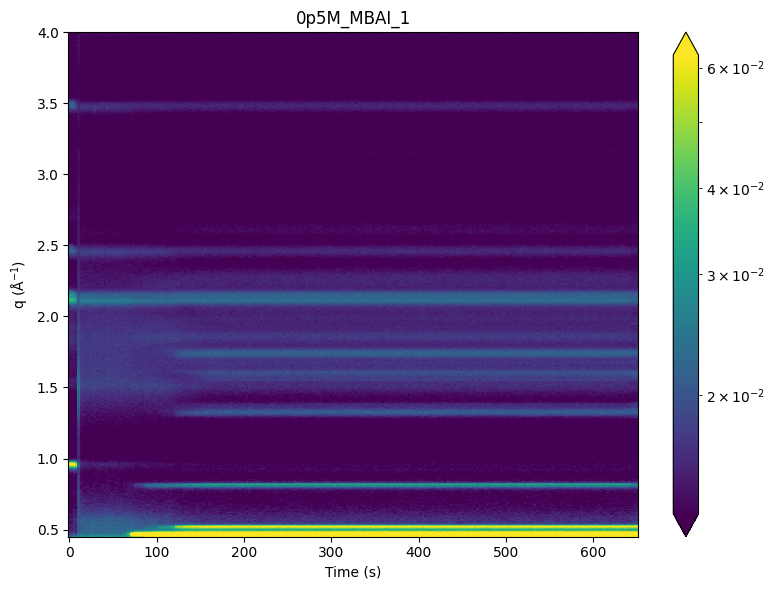

In [369]:
from matplotlib.colors import LogNorm
from numpy import percentile
fig, ax = plt.subplots(figsize=(8, 6))


# normalize data using min max normalization
data_array = (data_array - data_array.min()) / (data_array.max() - data_array.min()) + data_array.min()

data_array.plot.imshow(x="time", y="q_A^-1", cmap="viridis", norm=LogNorm(percentile(data_array, 50), percentile(data_array, 99)), ax=ax)

ax.set_ylabel(r"q (Å$^{-1}$)")
ax.set_xlabel("Time (s)")

ax.set_title(exp_dir.stem)

fig.tight_layout()
fig.savefig(nc_file_path.with_suffix('.png'), dpi=300)

# Plotting

In [1]:
import xarray as xr
from pathlib import Path
from natsort import natsorted


nc_files_dir = Path(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025")
nc_files = natsorted(nc_files_dir.glob("*.nc"))
print("\n".join([str(nc_file) for nc_file in nc_files]))

pdata_arrays = []

for nc_file in nc_files:
    if "combined" in nc_file.name:
        continue
    with xr.open_dataarray(nc_file) as da:
        pdata_arrays.append(da)

for da in pdata_arrays:
    print(f"{da.attrs['title']}: shape={da.shape}, time points={da.sizes['time']}, q range={da.coords['q_A^-1'].values[0]} to {da.coords['q_A^-1'].values[-1]}")


G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\0p1M_ClMBAI_1.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\0p5M_ClMBAI_1.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\0p5M_MBAI_1.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\0p5M_pMeOMBAI_1.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\1p0M_ClMBAI_1.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\1p0M_pMeOMBAI_1.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\1p5M_ClMBAI_1.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\1p5M_pMeOMBAI_1.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\giwaxs_combined_V1.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\insitu_0p5M_MeOMBAI_7.nc
G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\insitu_1p0M_ClMBAI_6r

In [2]:
dispense_frame = {
    '0p1M_ClMBAI_1': 6,
    '0p5M_ClMBAI_1': 6,
    '0p5M_MBAI_1': 5,
    '0p5M_pMeOMBAI_1': 5,
    '1p0M_ClMBAI_1': 5,
    '1p0M_pMeOMBAI_1': 5,
    '1p5M_ClMBAI_1': 5,
    '1p5M_pMeOMBAI_1': 5,
    'insitu_0p5M_MeOMBAI_7': 5,
    'insitu_1p0M_ClMBAI_6re': 5,
    'insitu_1p0M_MBAI_5': 7,
    'insitu_1p0M_MeOMBAI_6': 5
}

In [3]:
import pandas as pd
from matplotlib.colors import LogNorm
import numpy as np
import json


pdatasets = [pdata_array.to_dataset(name="intensity", promote_attrs=True) for pdata_array in pdata_arrays]
pdataset_names = [ds.attrs['title'] for ds in pdatasets]


synced_datasets = []
for ds in pdatasets:
    exp_name = ds.attrs['title']
    ds.attrs['tif_tags'] = json.loads(ds.attrs.get('tif_tags', '{}'))
    dispense_frame_num = dispense_frame.get(exp_name, None)
    if dispense_frame_num is not None:
        dispense_time = ds.where(ds['frame'] == dispense_frame_num, drop=True).time.values
        time_offset = -(dispense_time[0] - 5.0)
        print(f"Offsetting '{exp_name}' by dispense time {time_offset} seconds")
        ds = ds.assign_coords(time=(ds['time'] + time_offset))
        
    synced_datasets.append(ds)


def combine_attrs(list_of_attrs, context=None):
    samples = [attrs.get("title", "unknown") for attrs in list_of_attrs]
    return dict(zip(samples, [json.dumps(attrs, sort_keys=True) for attrs in list_of_attrs]))

pdataset = xr.concat(synced_datasets, dim=pd.Index(pdataset_names, name="experiment", dtype=np.str_), join="outer", combine_attrs=combine_attrs)
# pdataset
# pdataset.sel(experiment="0p5M_MBAI_1")["intensity"].dropna("time").plot.imshow(x="time", y="q_A^-1", cmap="viridis", norm=LogNorm())


twoTheta = np.rad2deg(2 * np.arcsin(pdataset["q_A^-1"] * 1.54 / (4 * np.pi))).values
pdataset = pdataset.assign_coords({"twoTheta_deg": ("q_A^-1", twoTheta)})
pdataset["sample_norm_int"] = pdataset["intensity"].groupby("experiment").apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# set non-exist frame to -1 for saving as integer
frames = np.nan_to_num(pdataset["frame"].values, nan=-1).astype(int)
pdataset = pdataset.assign_coords({"frame": (("experiment", "time"), frames)})

pdataset.to_netcdf(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\giwaxs_combined.nc", engine="netcdf4")

Offsetting '0p1M_ClMBAI_1' by dispense time -5.0 seconds
Offsetting '0p5M_ClMBAI_1' by dispense time -9.0 seconds
Offsetting '0p5M_MBAI_1' by dispense time -5.0 seconds
Offsetting '0p5M_pMeOMBAI_1' by dispense time -5.0 seconds
Offsetting '1p0M_ClMBAI_1' by dispense time -5.0 seconds
Offsetting '1p0M_pMeOMBAI_1' by dispense time -3.0 seconds
Offsetting '1p5M_ClMBAI_1' by dispense time -3.0 seconds
Offsetting '1p5M_pMeOMBAI_1' by dispense time -3.0 seconds
Offsetting 'insitu_0p5M_MeOMBAI_7' by dispense time -7.0 seconds
Offsetting 'insitu_1p0M_ClMBAI_6re' by dispense time -9.0 seconds
Offsetting 'insitu_1p0M_MBAI_5' by dispense time -3.0 seconds
Offsetting 'insitu_1p0M_MeOMBAI_6' by dispense time -3.0 seconds


In [10]:
pdataset

<xarray.Dataset> Size: 22MB
Dimensions:          (experiment: 12, time: 452, q_A^-1: 500)
Coordinates:
  * experiment       (experiment) object 96B '0p1M_ClMBAI_1' ... 'insitu_1p0M...
  * time             (time) float64 4kB -9.0 -7.0 -5.0 ... 697.0 699.0 701.0
    frame            (experiment, time) int64 43kB -1 -1 1 2 -1 ... -1 -1 -1 -1
  * q_A^-1           (q_A^-1) float64 4kB 0.3037 0.3111 0.3185 ... 3.989 3.996
    twoTheta_deg     (q_A^-1) float64 4kB 4.266 4.37 4.474 ... 58.41 58.53 58.65
Data variables:
    intensity        (experiment, time, q_A^-1) float32 11MB nan nan ... nan nan
    sample_norm_int  (experiment, time, q_A^-1) float32 11MB nan nan ... nan nan
Attributes:
    0p1M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    0p5M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    0p5M_MBAI_1:             {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    0p5M_pMeOMBAI_1:         {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p0M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p0M_pMeOMBAI_1:         {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p5M_ClMBAI_1:           {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    1p5M_pMeOMBAI_1:         {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    insitu_0p5M_MeOMBAI_7:   {"base_poni_file": "G:/Shared drives/Sutter-Fell...
    insitu_1p0M_ClMBAI_6re:  {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    insitu_1p0M_MBAI_5:      {"base_poni_file": "G:\\Shared drives\\Sutter-Fe...
    insitu_1p0M_MeOMBAI_6:   {"base_poni_file": "G:/Shared drives/Sutter-Fell...

In [2]:
import xarray as xr
pdataset = xr.open_dataset(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\giwaxs_combined.nc", engine="netcdf4")

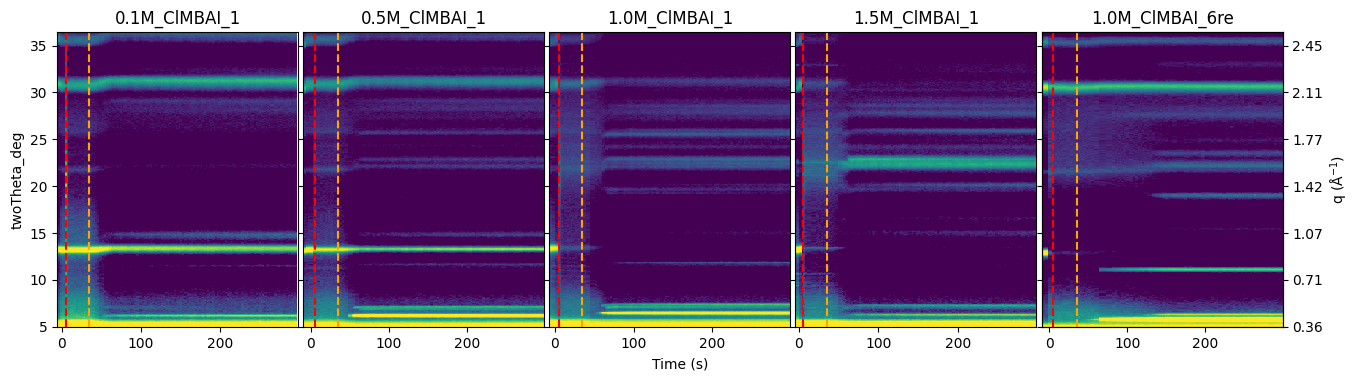

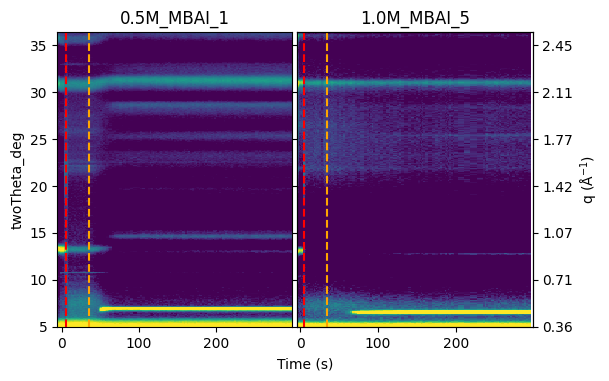

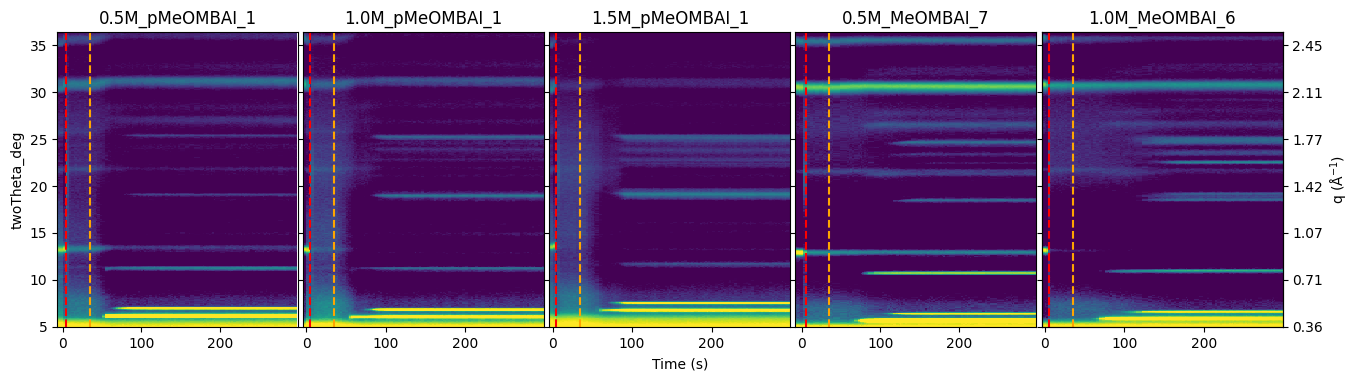

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from numpy import percentile
import numpy as np


for exp in ['ClMBAI', 'MBAI', 'p?MeOMBAI']:
# for exp in ['0p5']:

    ds_by_material = pdataset.where(pdataset["experiment"].str.contains(f"M_{exp}", case=False), drop=True)
    # ds_by_material = pdataset.where(pdataset["experiment"].str.contains(f"{exp}", case=False), drop=True)

    da_by_material = ds_by_material["sample_norm_int"]
    da_by_material = da_by_material.sel(**{"time": slice(None, 300), "q_A^-1": slice(0.35, 2.55)})
    num_exps = len(da_by_material.experiment)
    fig, axes = plt.subplots(1, num_exps, figsize=(num_exps * 2.5 + 1.2, 4), sharey=True)

    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    for i, (exp_name, exp) in enumerate(da_by_material.groupby("experiment")):
        exp = exp.dropna("time")
        exp.plot(
            x="time", y="twoTheta_deg", ax=axes[i], norm=LogNorm(percentile(exp, 50), percentile(exp, 98)), cmap="viridis", cbar_ax=None
        )
        axes[i].set_title(exp_name.replace("p", ".", 1).replace("insitu_", ""))

        # remove colorbar for all but last
        axes[i].collections[0].colorbar.remove()

        if i > 0:
            axes[i].set_ylabel("")
        
        axes[i].set_xlabel("")
        axes[i].set_xlim(None, da_by_material.time.max())
        
        # draw dispense time (5s) line and heating start line (30s)
        axes[i].axvline(5, color='red', linestyle='--', label='Dispense Time')
        axes[i].axvline(35, color='orange', linestyle='--', label='Heating Start')

    fig.supxlabel("Time (s)", y=0.06, fontsize=10)

    ax_right = axes[-1].twinx()
    ax_right.set_ylabel(r"q (Å$^{-1}$)")
    y_lim = axes[-1].get_ylim()
    ticks = axes[-1].get_yticks()
    ax_right.set_yticks(ticks, labels=[f"{np.round(np.sin(np.deg2rad(tth/2)) * 4 * np.pi / 1.54, 2)}" for tth in ticks])
    ax_right.set_ylim(y_lim)
    axes[-1].set_ylim(y_lim)
    fig.tight_layout(w_pad=0.02)
    

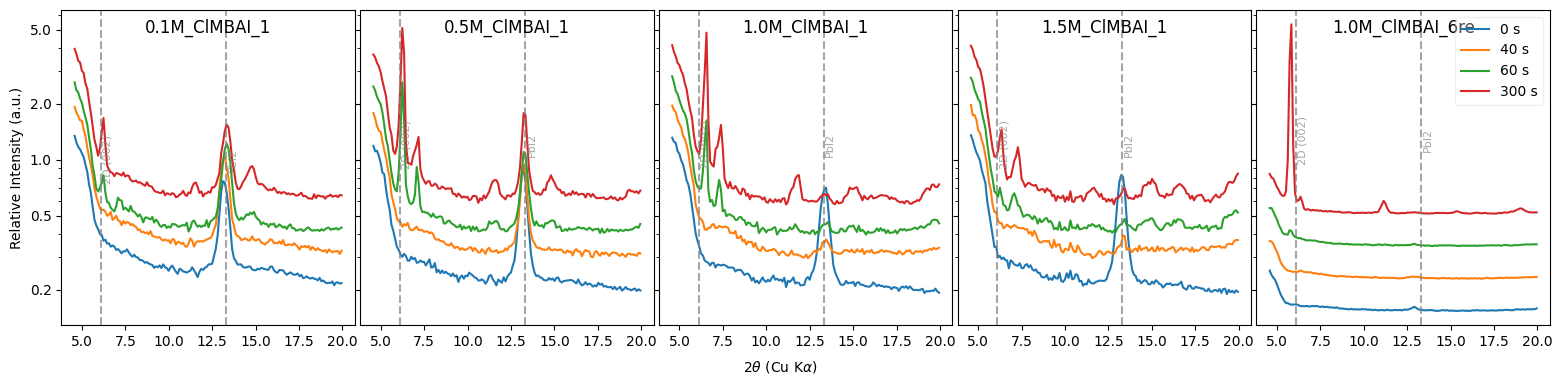

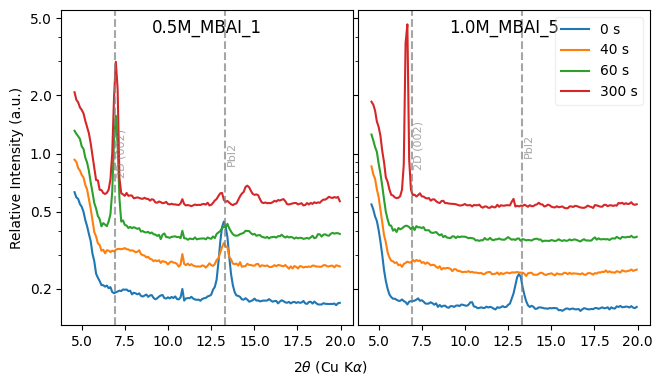

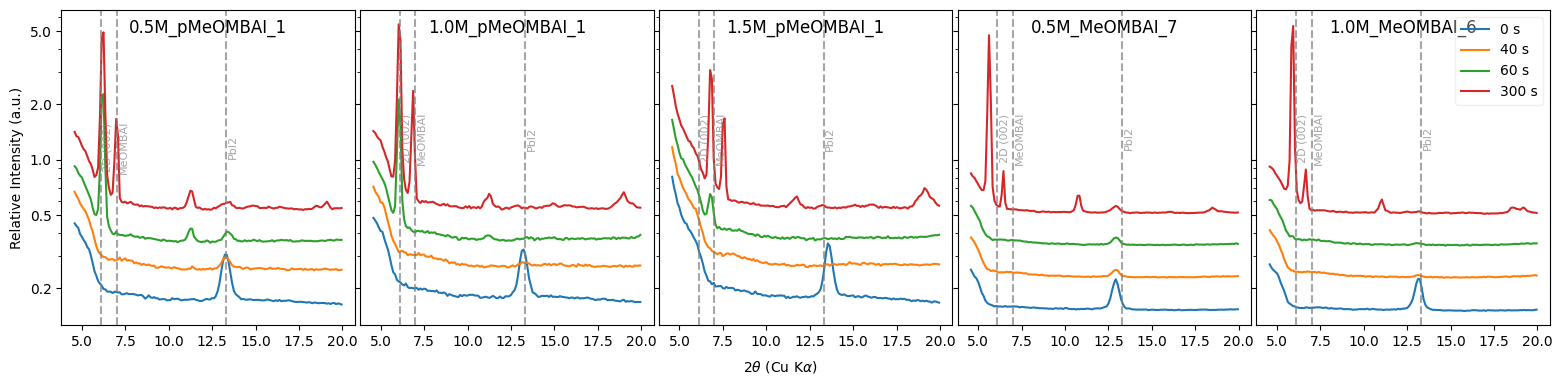

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from numpy import percentile

peaks_of_interest_with_phase = {
    "MBAI": [(6.9, 2, "2D (002)"), (13.3, 2, "PbI2")],
    "ClMBAI": [(6.1, 2, "2D (002)"), (13.3, 2, "PbI2")],
    "p?MeOMBAI": [(6.1, 0.5, "2D (002)"), (7.0, 0.5, "MeOMBAI"), (13.3, 2, "PbI2")]
}

for exp_group in ['ClMBAI', 'MBAI', 'p?MeOMBAI']:
# for exp in ['1p0']:

    ds_by_material = pdataset.where(pdataset["experiment"].str.contains(f"M_{exp_group}", case=False), drop=True)
    # ds_by_material = pdataset.where(pdataset["experiment"].str.contains(f"{exp}", case=False), drop=True)

    da_by_material = ds_by_material["sample_norm_int"].swap_dims({"q_A^-1": "twoTheta_deg"})
    da_by_material = da_by_material.sel(**{"twoTheta_deg": slice(4.5, 20)})

    num_exps = len(da_by_material.experiment)
    fig, axes = plt.subplots(1, num_exps,  figsize=(num_exps * 3 + 0.7, 4), sharey=True)

    for i, (exp_name, exp) in enumerate(da_by_material.groupby("experiment")):

        time_of_interest = [0, 40, 60 ,300]
        da = exp[0].dropna("time")
        da = da.sel(time=time_of_interest, method="nearest")

        for j in range(len(time_of_interest)):
            # offset for stack plot and baseline shift to prevent log scale issues with too low values
            da[j, :] = (da[j, :] + 0.1) * 1.5 ** (j+1) 

        da.plot.line(x="twoTheta_deg", ax=axes[i], add_legend=False)
        axes[i].set_title(exp_name.replace("p", ".", 1).replace("insitu_", ""), y=0.9)

        axes[i].set_yscale("log")
        yticks = [0.2, 0.5, 1.0, 2.0, 5.0]
        axes[i].set_yticks(yticks, labels=[str(ytick) for ytick in yticks])
        
        # remove y label for all but first
        if i > 0:
            axes[i].set_ylabel("")
        else:
            axes[i].set_ylabel("Relative Intensity (a.u.)")
        
        axes[i].set_xlabel("")

        for peak_pos, phase, phase_name in peaks_of_interest_with_phase[exp_group]:
            axes[i].axvline(peak_pos, color='gray', linestyle='--', alpha=0.7)
            axes[i].text(peak_pos + 0.1, axes[i].get_ylim()[1]/5, phase_name, rotation=90, verticalalignment='center', color='gray', alpha=0.7, fontsize=8)

    axes[-1].legend(labels=[f"{t:.0f} s" for t in time_of_interest], framealpha=0.3)

    fig.supxlabel(r"2$\theta$ (Cu K$\alpha$)", y=0.05, fontsize=10)
    fig.tight_layout(w_pad=0.02)

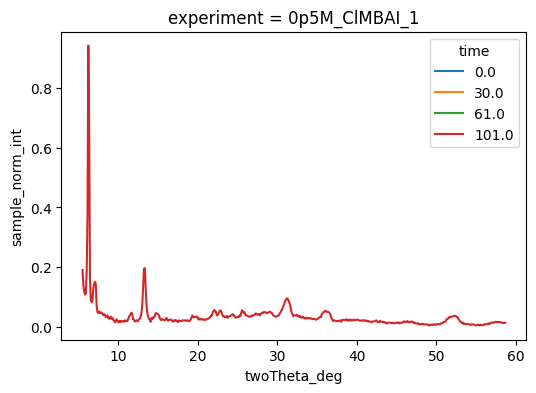

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from numpy import percentile
import xarray as xr

pdataset = xr.open_dataset(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\giwaxs_combined.nc")

sample_1 = pdataset.isel(experiment=1)

fig, ax = plt.subplots(figsize=(6,4))

sample_1 = sample_1.swap_dims({"q_A^-1": "twoTheta_deg"})

sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, None)).sel(time=[0, 30, 60, 100], method='nearest').plot.line(x="twoTheta_deg", ax=ax)